In [1]:
!pip install ultralytics opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.9 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import cv2
from IPython.display import Video, display

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [3]:
model = YOLO("yolov8n.pt")

In [4]:
from google.colab import files

uploaded = files.upload()


Saving highway.mp4.mp4 to highway.mp4.mp4


In [5]:
# Load yolo
MODEL_PATH = "yolov8n.pt"

model = YOLO(MODEL_PATH)

class_list = model.names

print("YOLO model loaded successfully!")

YOLO model loaded successfully!


In [6]:
class_list

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [7]:
CLASSES = [2, 3, 5, 7]

print("Vehicle classes selected:", CLASSES)

Vehicle classes selected: [2, 3, 5, 7]


In [8]:
INPUT_PATH = list(uploaded.keys())[0]

print("Video selected:", INPUT_PATH)

Video selected: highway.mp4.mp4


In [9]:
cap = cv2.VideoCapture(INPUT_PATH)

if not cap.isOpened():
    print(" Cannot open video")
else:
    print(" Video opened successfully")

cap.release()

 Video opened successfully


In [10]:
cap = cv2.VideoCapture(INPUT_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

cap.release()

print("FPS:", fps)
print("Width:", width)
print("Height:", height)
print("Total Frames:", total_frames)

FPS: 50.0
Width: 1920
Height: 1080
Total Frames: 700


In [11]:

# Testong yolo on one frame
cap = cv2.VideoCapture(INPUT_PATH)

ret, frame = cap.read()

cap.release()

if ret:
    print("First frame extracted successfully!")
else:
    print(" Could not read frame")

First frame extracted successfully!


In [12]:
# yolo detection
results = model(
    frame,
    classes=CLASSES,
    conf=0.5,
    verbose=False
)

print("YOLO detection completed!")

YOLO detection completed!


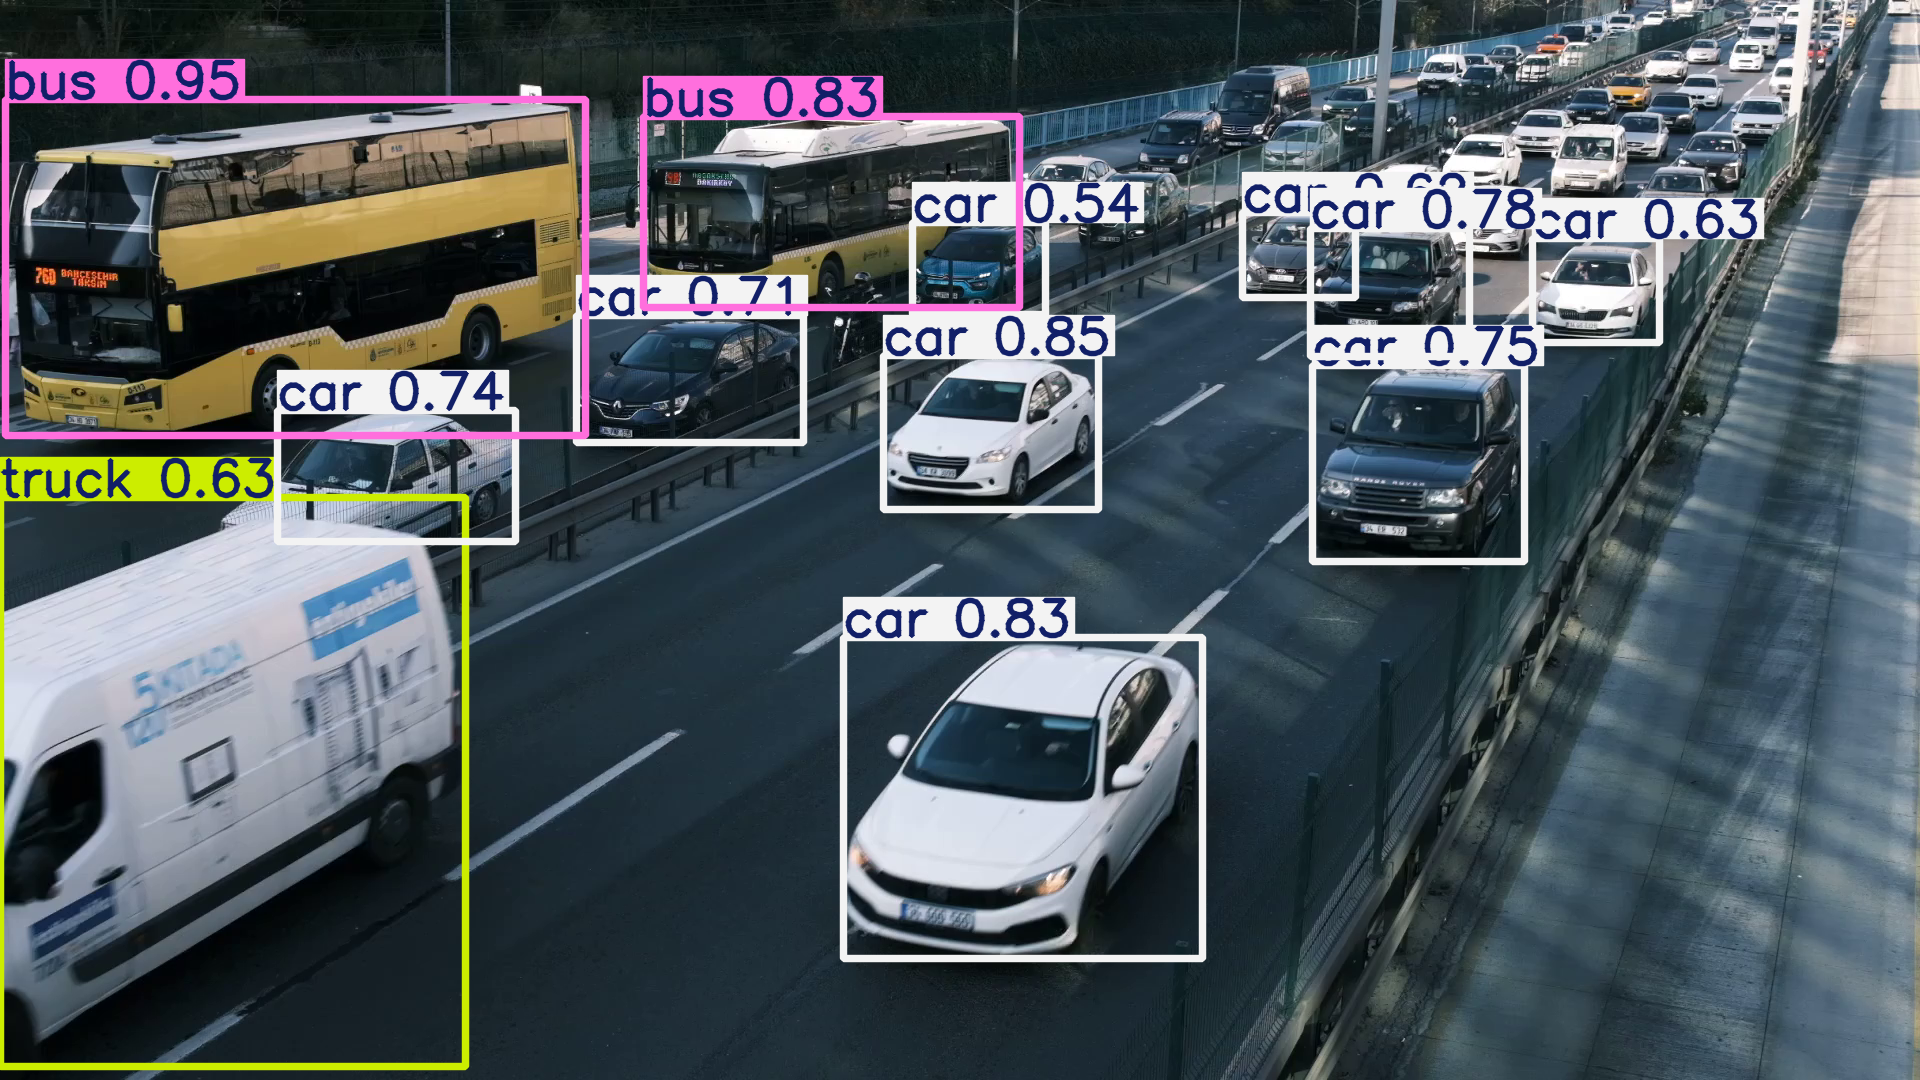

In [13]:
# Displaying the detected frame
annotated_frame = results[0].plot()

from google.colab.patches import cv2_imshow

cv2_imshow(annotated_frame)

In [14]:
from collections import defaultdict

class_counts = defaultdict(int)
crossed_ids = set()
output_data = []

print("Tracking variables created successfully!")

Tracking variables created successfully!


In [15]:
FRAME_SKIP = 2
RESIZE_WIDTH = 960

LINE_Y = 430

print("Tracking configuration ready!")

Tracking configuration ready!


In [16]:
# Output video
output_path = "predicted_highway.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (RESIZE_WIDTH, int(height * RESIZE_WIDTH / width))
)

print("Output video created!")

Output video created!


In [17]:
cap = cv2.VideoCapture(INPUT_PATH)

frame_count = 0

print("Video processing started...")

Video processing started...


In [19]:
while cap.isOpened():

    ret, frame = cap.read()

    if not ret:
        break

    frame_count += 1

    if frame_count % FRAME_SKIP != 0:
        continue

    # Resize frame
    scale = RESIZE_WIDTH / frame.shape[1]

    frame = cv2.resize(
        frame,
        (
            RESIZE_WIDTH,
            int(frame.shape[0] * scale)
        )
    )

    # YOLO tracking
    results = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        classes=CLASSES,
        conf=0.5,
        verbose=False
    )

    result = results[0]

    # Draw counting line
    cv2.line(
        frame,
        (0, LINE_Y),
        (frame.shape[1], LINE_Y),
        (0, 0, 255),
        3
    )

    # Check tracking IDs
    if result.boxes.id is not None:

        boxes = result.boxes.xyxy
        track_ids = result.boxes.id.int()
        class_indices = result.boxes.cls.int()
        confidences = result.boxes.conf

        for box, track_id, cls_idx, conf in zip(
            boxes,
            track_ids,
            class_indices,
            confidences
        ):

            x1, y1, x2, y2 = map(int, box)

            track_id = int(track_id)
            class_id = int(cls_idx)

            confidence = float(conf)

            class_name = class_list[class_id]

            # Center of object
            center_x = (x1 + x2) // 2
            center_y = (y1 + y2) // 2

            # Draw bounding box
            cv2.rectangle(
                frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

            # Label
            label = f"{class_name} ID:{track_id}"

            cv2.putText(
                frame,
                label,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 255),
                2
            )

            # Center point
            cv2.circle(
                frame,
                (center_x, center_y),
                4,
                (255, 0, 0),
                -1
            )

            # Count when crossing line
            if (
                center_y > LINE_Y
                and track_id not in crossed_ids
            ):

                crossed_ids.add(track_id)

                class_counts[class_name] += 1

                output_data.append({
                    "Track_ID": track_id,
                    "Class": class_name,
                    "Confidence": confidence,
                    "Frame_No": frame_count,
                    "Source": "Video"
                })

    # Display counts
    y = 30

    for cls, count in class_counts.items():

        cv2.putText(
            frame,
            f"{cls}: {count}",
            (20, y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 255, 0),
            2
        )

        y += 30

    # Save frame
    out.write(frame)

print("Video processing completed!")

Video processing completed!


In [20]:
cap.release()
out.release()

print("Video resources released!")

Video resources released!


In [21]:
import os

if os.path.exists(output_path):

    size = os.path.getsize(output_path) / (1024 * 1024)

    print(" Output video created")
    print("File:", output_path)
    print("Size:", round(size, 2), "MB")

else:

    print("Output video not found")

 Output video created
File: predicted_highway.mp4
Size: 17.7 MB


In [23]:
from google.colab import files

files.download("predicted_highway.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

df_output = pd.DataFrame(output_data)

df_output

,Track_ID,Class,Confidence,Frame_No,Source
0,2,car,0.858663,16,Video
1,18,car,0.609629,50,Video
2,5,car,0.888472,144,Video
3,4,car,0.923551,166,Video
4,9,car,0.907620,308,Video
5,6,car,0.885324,354,Video
6,13,car,0.906591,502,Video
7,10,car,0.930789,504,Video
8,16,car,0.915682,596,Video
9,23,car,0.924253,668,Video
